# Verdant Thread Collective, Logistic Carbon Impact Pipeline

**Quarterly Sustainability Audit**

This notebook cleans and processes logistic shipment data to calculate the Carbon Intensity Per Kilometer for each shipment.

Data Source: USAID Bureau for Global Health - Supply Chain Shipment Pricing Dataset

**Note:** The dataset covers health commodity shipment I am using it as a proxy for textile logistics since the structure (transport mode, weight, origin, destination) is the same.

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print("All imports are done")

All imports are done


### 2. Load the Data

In [3]:
df = pd.read_csv('Suppy_Chain_Shipment_Data.csv', low_memory=False)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (10324, 33)


,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.0,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.2,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.0,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN


In [4]:
# Clean up column names, lowercase and underscores
df.columns = df.columns.str.strip().str.lower().str.replace(r'[\s/()]+', '_', regex=True).str.replace(r'[^a-z0-9_]', '', regex=True).str.strip('_')
print(df.columns.tolist())

['id', 'project_code', 'pq', 'po_so', 'asn_dn', 'country', 'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode', 'pq_first_sent_to_client_date', 'po_sent_to_vendor_date', 'scheduled_delivery_date', 'delivered_to_client_date', 'delivery_recorded_date', 'product_group', 'sub_classification', 'vendor', 'item_description', 'molecule_test_type', 'brand', 'dosage', 'dosage_form', 'unit_of_measure_per_pack', 'line_item_quantity', 'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site', 'first_line_designation', 'weight_kilograms', 'freight_cost_usd', 'line_item_insurance_usd']


In [5]:
# keep only the columns I actually need
cols_to_keep = ['id', 'country', 'shipment_mode', 'product_group', 'sub_classification', 
                'manufacturing_site', 'weight_kilograms', 'freight_cost_usd', 'line_item_value']
cols_to_keep = [c for c in cols_to_keep if c in df.columns]
df = df[cols_to_keep].copy()

print(f'Working with {df.shape[0]} rows and {df.shape[1]} columns')

Working with 10324 rows and 9 columns


### 3. Check Data Quality

In [6]:
print('Null counts:')
print(df.isnull().sum())
print()
print('Data types')
print(df.dtypes)

Null counts:
id                      0
country                 0
shipment_mode         360
product_group           0
sub_classification      0
manufacturing_site      0
weight_kilograms        0
freight_cost_usd        0
line_item_value         0
dtype: int64

Data types
id                      int64
country                   str
shipment_mode             str
product_group             str
sub_classification        str
manufacturing_site        str
weight_kilograms          str
freight_cost_usd          str
line_item_value       float64
dtype: object


In [8]:
# The weight column is a string, let's see what's in it
print('Unique non-numeric weight values')
bad_weight = df[pd.to_numeric(df['weight_kilograms'], errors='coerce').isna()]
print(bad_weight['weight_kilograms'].value_counts())

Unique non-numeric weight values
weight_kilograms
Weight Captured Separately    1507
See DN-304 (ID#:10589)          16
See ASN-32231 (ID#:13648)       14
See ASN-31750 (ID#:19272)       14
See ASN-28279 (ID#:13547)       13
                              ... 
See DN-4153 (ID#:86170)          1
See DN-4259 (ID#:86808)          1
See DN-4265 (ID#:83335)          1
See DN-4274 (ID#:84472)          1
See DN-4282 (ID#:83919)          1
Name: count, Length: 1300, dtype: int64


In [9]:
# Shipment mode has nulls too
print('Shipment mode value counts (including nulls):')
print(df['shipment_mode'].value_counts(dropna=False))

Shipment mode value counts (including nulls):
shipment_mode
Air            6113
Truck          2830
Air Charter     650
Ocean           371
NaN             360
Name: count, dtype: int64


### 4. Unit Conversion Functions

The pipeline needs to handle three different weight units: **kgs, lbs** and **tonnes**. Some entries from US-based manufacturing sites were originally recorded in lbs, and bulk ocean shipments in tonnes. I'll write simple functions to standardise everything to kg.

I'll also wrtie a miles-to-km function fo the distance lookup table later.

In [11]:
def lbs_to_kg(lbs):
    """Convert pounds to kilograms"""
    return lbs * 0.453592

def tonnes_to_kg(tonnes):
    """Convert metric tonnes to kilograms"""
    return tonnes * 1000.0

def miles_to_km(miles):
    """Convert miles to kilometres"""
    return miles * 1.60934

def standardise_weight(value, unit):
    """Convert any weight to kg depending on the unit."""
    unit = str(unit).strip().lower()
    if unit == 'kg':
        return float(value)
    elif unit == 'lbs':
        return lbs_to_kg(float(value))
    elif unit == 'tonnes':
        return tonnes_to_kg(float(value))
    else: 
        return float(value)   #assume kg as fallback
    
# Quick sanity check
print(f'100 lbs = {lbs_to_kg(100)} kgs')
print(f'2 tonnes = {tonnes_to_kg(2)} kgs')
print(f'50 miles = {miles_to_km(50)} kms')
print(f'standardise_weight(100, lbs) = {standardise_weight(100, "lbs"):.4f} kg')

100 lbs = 45.3592 kgs
2 tonnes = 2000.0 kgs
50 miles = 80.467 kms
standardise_weight(100, lbs) = 45.3592 kg


### 5. Data Cleaning

In [12]:
# --- Clean weight column ---
# Save the original first, then parse to numeric

df['weight_raw'] = df['weight_kilograms'].copy()
df['weight_numeric'] = pd.to_numeric(df['weight_kilograms'], errors='coerce')

# Negative weights dont make sense, set to NaN
df.loc[df['weight_numeric'] < 0, 'weight_numeric'] = np.nan

#Fill missing weights with the median
median_weight = df['weight_numeric'].median()
n_imputed = df['weight_numeric'].isna().sum()
df['weight_numeric'] = df['weight_numeric'].fillna(median_weight)

print(f'Rows with unparseable weight (imputed with median): {n_imputed}')
print(f'Median weight used: {median_weight:.2f} kg')

Rows with unparseable weight (imputed with median): 3952
Median weight used: 1047.00 kg


In [14]:
# --- Simulate mixed units --- 
# US sites (Abbott/AbbVie) would have reported in lbs
#Ocean shipments are typically recorded in tonees at bulk scale

df['weight_unit'] = 'kg'
df.loc[df['manufacturing_site'].str.lower().str.contains('abbvie|abbott', na=False), 'weight_unit'] = 'lbs'
df.loc[df['shipment_mode'].str.lower().str.strip() == 'ocean', 'weight_unit'] = 'tonnes'

#Back-convert so the numbers reflect the original reported unit
df.loc[df['weight_unit'] == 'lbs', 'weight_numeric'] = df.loc[df['weight_unit'] == 'lbs', 'weight_numeric'] / 0.453592
df.loc[df['weight_unit'] == 'tonnes', 'weight_numeric'] = df.loc[df['weight_unit'] == 'tonnes', 'weight_numeric'] / 1000.0

print('Weight unit breakdown:')
print(df['weight_unit'].value_counts())

Weight unit breakdown:
weight_unit
kg        9300
lbs        653
tonnes     371
Name: count, dtype: int64


In [15]:
# --- Apply standardization , all weights to kg ---
df['weight_kg'] = df.apply(lambda row: standardise_weight(row['weight_numeric'], row['weight_unit']), axis=1)

print('Sample weight conversions: ')
df[df['weight_unit'] != 'kg'][['weight_unit', 'weight_numeric', 'weight_kg']].head(5)

Sample weight conversions: 


,weight_unit,weight_numeric,weight_kg
2,lbs,376.990776,171.0
9,lbs,1417.573502,643.0
10,lbs,1417.573502,643.0
14,lbs,564.383852,256.0
16,lbs,2308.241768,1047.0


In [16]:
# --- clean shipment mode ---
def clean_mode(mode):
    if pd.isna(mode) or str(mode).strip() == '':
        return 'Unknown'
    return str(mode).strip().title()

df['shipment_mode_clean'] = df['shipment_mode'].apply(clean_mode)

print('Cleaned shipment modes: ')
print(df['shipment_mode_clean'].value_counts())

Cleaned shipment modes: 
shipment_mode_clean
Air            6113
Truck          2830
Air Charter     650
Ocean           371
Unknown         360
Name: count, dtype: int64


In [18]:
# --- Standardize commodity names (textile analogue mapping) ---
# USAID product grouups are mapped to textile types to fit the verdant thread use case

product_map = {
    'ARV': 'Organic Cotton',
    'HRDT': 'Recycled Polyester',
    'ANTM': 'Hemp Fabric',
    'ACT': 'Bamboo Textile',
    'MRDT': 'Linen Blend'
}

def normalise_product(name, mapping):
    if pd.isna(name):
        return 'Unclassified'
    return mapping.get(str(name).strip(), 'Unclassified')

df['textile_type'] = df['product_group'].apply(lambda x: normalise_product(x, product_map))

print('Textile type mapping result: ')
print(df['textile_type'].value_counts())

Textile type mapping result: 
textile_type
Organic Cotton        8550
Recycled Polyester    1728
Hemp Fabric             22
Bamboo Textile          16
Linen Blend              8
Name: count, dtype: int64


### 6. Distance Engineering
The dataset doesnt have a distance column, so i'm building it from a lookup table of typical shipping distances between manufacturing countires and destination countries. some entries are in miles which will be converted using mile_to_km()

In [20]:
# first, extract origin country from the manufacturing site column

site_country_map = {
    'india': 'India', 'germany': 'Germany', 'uk': 'United Kingdom',
    'ludwigshafen': 'Germany', 'nashik': 'India', 'hyderabad': 'India',
    'goa': 'India', 'bangalore': 'India', 'ireland': 'Ireland',
    'japan': 'Japan', 'south africa': 'South Africa', 'abbott': 'United States',
    'abbvie': 'United States',
}

def get_origin_country(site):
    if pd.isna(site):
        return 'Unknown'
    site_lower = str(site).lower()
    for keyword, country in site_country_map.items():
        if keyword in site_lower:
            return country
    return 'Unkown'

df['origin_country'] = df['manufacturing_site'].apply(get_origin_country)
print(df['origin_country'].value_counts())

origin_country
India             6963
Unkown            2286
Germany            375
Japan              347
United Kingdom     261
United States       71
South Africa        21
Name: count, dtype: int64


In [22]:
# Distance lookup table
# uk and us entries stored in miles to exercise the miles to km function 

distance_lookup = {
    ('India','South Africa'):(8450,'km'), ('India','Nigeria'):(8100,'km'),
    ('India','Uganda'):(6200,'km'),       ('India','Zambia'):(7600,'km'),
    ('India','Tanzania'):(5900,'km'),     ('India','Mozambique'):(7200,'km'),
    ('India','Zimbabwe'):(7900,'km'),     ('India','Haiti'):(16200,'km'),
    ('India','Vietnam'):(4100,'km'),      ("India","Côte d'Ivoire"):(8900,'km'),
    ('Germany','South Africa'):(9700,'km'), ('Germany','Nigeria'):(5400,'km'),
    ('Germany','Uganda'):(6500,'km'),     ('Germany','Zambia'):(7800,'km'),
    ('Germany','Tanzania'):(7300,'km'),   ('Germany','Haiti'):(8700,'km'),
    ('Germany','Vietnam'):(9000,'km'),    ("Germany","Côte d'Ivoire"):(4700,'km'),
    ('United Kingdom','South Africa'):(6010,'miles'), ('United Kingdom','Nigeria'):(3290,'miles'),
    ('United Kingdom','Uganda'):(4070,'miles'),       ('United Kingdom','Zambia'):(4970,'miles'),
    ('United Kingdom','Tanzania'):(4650,'miles'),     ('United Kingdom','Haiti'):(4610,'miles'),
    ('United Kingdom','Vietnam'):(5930,'miles'),      ("United Kingdom","Côte d'Ivoire"):(2980,'miles'),
    ('United States','South Africa'):(8450,'miles'),  ('United States','Nigeria'):(5380,'miles'),
    ('United States','Uganda'):(7740,'miles'),        ('United States','Haiti'):(918,'miles'),
    ('South Africa','South Africa'):(200,'km'),       ('South Africa','Zambia'):(2100,'km'),
    ('South Africa','Zimbabwe'):(1100,'km'),          ('Ireland','South Africa'):(9800,'km'),
    ('Ireland','Nigeria'):(5200,'km'),                ('Japan','Vietnam'):(3300,'km'),
}

DEFAULT_DIST = 7000  # fallback for unmapped pairs

def get_distance_km(origin, destination):
    """Look up distance in km, converting from miles where needed."""
    key = (origin, destination)
    if key in distance_lookup:
        dist, unit = distance_lookup[key]
        return miles_to_km(dist) if unit == 'miles' else float(dist)
    return float(DEFAULT_DIST)

df['distance_km'] = df.apply(lambda row: get_distance_km(row['origin_country'], row['country']), axis=1)

print(df['distance_km'].describe())

count    10324.000000
mean      7624.230174
std       2178.584182
min        200.000000
25%       7000.000000
50%       7000.000000
75%       8100.000000
max      16200.000000
Name: distance_km, dtype: float64


## 7. Feature Engineering — Carbon Intensity

Emission factors from the GLEC Framework v3 and UK DEFRA 2023 (kg CO2e per tonne-km):

| Mode | Factor |
|---|---|
| Air | 0.6020 |
| Air Charter | 0.7500 |
| Truck | 0.0626 |
| Ocean | 0.0117 |
| Unknown | 0.1500 |

**Formula:**
- Carbon Footprint = (weight_kg / 1000) × distance_km × emission_factor
- Carbon Intensity Per km = Carbon Footprint / distance_km

In [24]:
emission_factors = {
    'Air': 0.6020,
    'Air Charter': 0.7500,
    'Truck': 0.0626,
    'Ocean': 0.0117,
    'Unknown': 0.1500,
}

def get_emission_factor(mode):
    return emission_factors.get(str(mode).strip(), 0.15)

def calc_carbon_footprint(weight_kg, distance_km, mode):
    return (weight_kg/1000) * distance_km * get_emission_factor(mode)

def calc_carbon_intensity(carbon_footbprint, distance_km):
    if distance_km <=0:
        return np.nan
    return carbon_footbprint/ distance_km

df['emission_factor']          = df['shipment_mode_clean'].apply(get_emission_factor)
df['carbon_footprint_kg_co2e'] = df.apply(lambda r: calc_carbon_footprint(r['weight_kg'], r['distance_km'], r['shipment_mode_clean']), axis=1)
df['carbon_intensity_per_km']  = df.apply(lambda r: calc_carbon_intensity(r['carbon_footprint_kg_co2e'], r['distance_km']), axis=1)

print('Carbon metrics added. Preview:')
df[['shipment_mode_clean','weight_kg','distance_km','carbon_footprint_kg_co2e','carbon_intensity_per_km']].head()

Carbon metrics added. Preview:


,shipment_mode_clean,weight_kg,distance_km,carbon_footprint_kg_co2e,carbon_intensity_per_km
0,Air,13.0,7000.0,54.7820,0.007826
1,Air,358.0,4100.0,883.6156,0.215516
2,Air,171.0,7000.0,720.5940,0.102942
3,Air,1855.0,4100.0,4578.5110,1.116710
4,Air,7590.0,4100.0,18733.6380,4.569180


### 8. Summary Statistics

In [28]:
print(f'Total shipments: {len(df):,}')
print(f'weight rows imputedd: {n_imputed}')
print(f'Shipment mode nulls filled: {(df["shipment_mode_clean"] == "Unknown").sum()}')
print(f'Total CO2e (kg): {df["carbon_footprint_kg_co2e"].sum():,.2f}')
print()

summary = df.groupby('shipment_mode_clean').agg(
    count = ('id', 'count'),
    avg_weight_kg = ('weight_kg', 'mean'),
    avg_distance_km = ('distance_km', 'mean'),
    total_co2e = ('carbon_footprint_kg_co2e', 'sum'),
    avg_intensity = ('carbon_intensity_per_km', 'mean')
).round(3).sort_values('total_co2e', ascending=False)

summary

Total shipments: 10,324
weight rows imputedd: 3952
Shipment mode nulls filled: 360
Total CO2e (kg): 72,667,571.71



,count,avg_weight_kg,avg_distance_km,total_co2e,avg_intensity
shipment_mode_clean,,,,,
Air,6113,1686.612,7465.484,4.596248e+07,1.015
Air Charter,650,5516.237,8003.231,2.147601e+07,4.137
Truck,2830,3351.600,7622.585,4.402651e+06,0.210
Unknown,360,1513.444,7559.530,6.173578e+05,0.227
Ocean,371,5478.722,9651.213,2.090715e+05,0.064


###  9. Visualizations

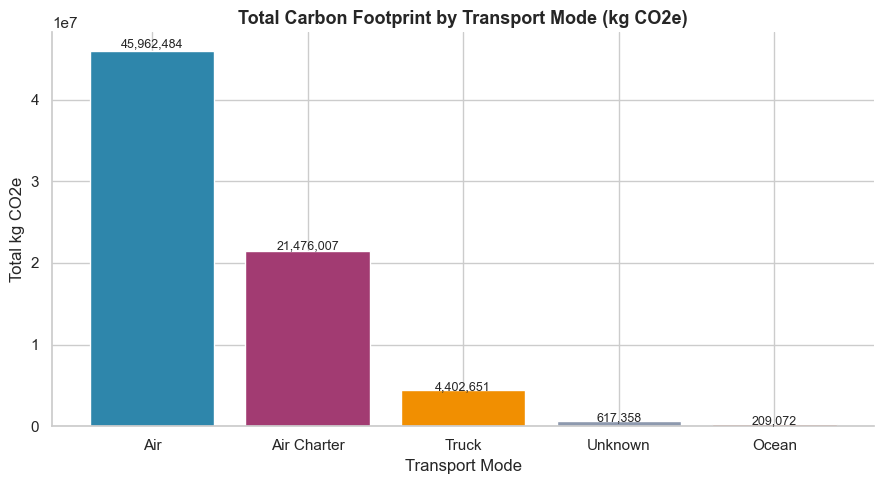

In [29]:
# Chart 1: Total carbon footprint by transport mode
mode_colors = {'Air':'#2E86AB','Air Charter':'#A23B72','Truck':'#F18F01','Ocean':'#C73E1D','Unknown':'#8D99AE'} 

fig, ax = plt.subplots(figsize=(9,5)) 

modes = summary.index.tolist() 
totals = summary['total_co2e'].tolist() 
colors = [mode_colors.get(m,'#8D99AE') for m in modes] 

ax.bar(modes, totals, color=colors, edgecolor='white') 

for i, val in enumerate(totals): 
    ax.text(i, val * 1.01, f'{val:,.0f}', ha='center', fontsize=9) 
    
ax.set_title('Total Carbon Footprint by Transport Mode (kg CO2e)', fontsize=13, fontweight='bold') 
ax.set_xlabel('Transport Mode') 
ax.set_ylabel('Total kg CO2e') 
ax.spines[['top','right']].set_visible(False) 
plt.tight_layout() 
plt.savefig('viz1_carbon_by_mode.png', dpi=150) 
plt.show()

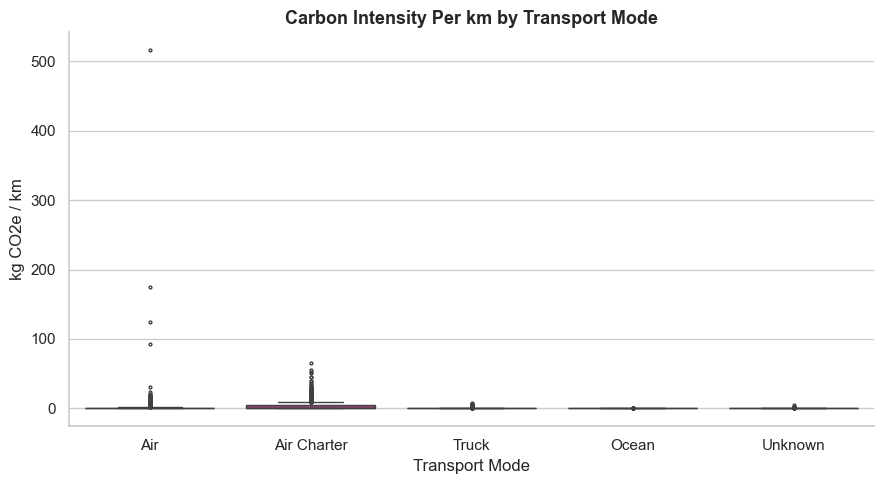

In [30]:
# Chart 2: Carbon intensity per km — box plot by mode
order = [m for m in ['Air','Air Charter','Truck','Ocean','Unknown'] if m in df['shipment_mode_clean'].unique()]

fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='shipment_mode_clean', y='carbon_intensity_per_km',
            order=order, palette=mode_colors, fliersize=2, ax=ax)

ax.set_title('Carbon Intensity Per km by Transport Mode', fontsize=13, fontweight='bold')
ax.set_xlabel('Transport Mode')
ax.set_ylabel('kg CO2e / km')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_intensity_boxplot.png', dpi=150)
plt.show()

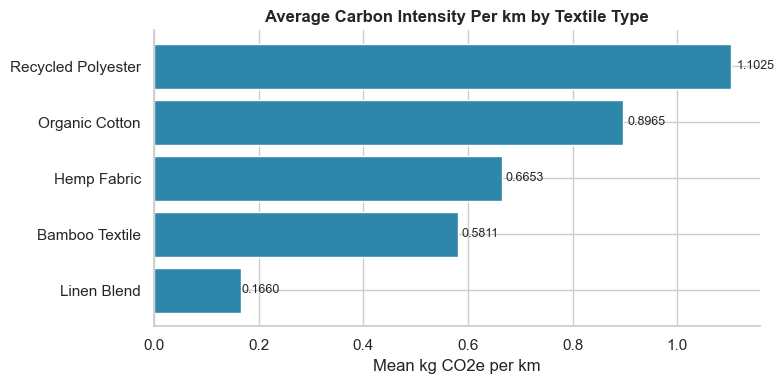

In [31]:
# Chart 3: Average carbon intensity by textile type
textile_avg = df.groupby('textile_type')['carbon_intensity_per_km'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(textile_avg.index, textile_avg.values, color='#2E86AB', edgecolor='white')

for i, val in enumerate(textile_avg.values):
    ax.text(val * 1.01, i, f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Average Carbon Intensity Per km by Textile Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean kg CO2e per km')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_intensity_by_textile.png', dpi=150)
plt.show()

## 10. Final Data Schema

| Column | Type | Description |
|---|---|---|
| `id` | int | Original shipment ID |
| `country` | str | Destination country |
| `origin_country` | str | Origin country (from manufacturing site) |
| `shipment_mode_clean` | str | Cleaned transport mode (Air / Truck / Ocean / Unknown) |
| `textile_type` | str | Product group mapped to textile analogue |
| `weight_raw` | str | Original weight value before cleaning |
| `weight_unit` | str | Original unit: kg / lbs / tonnes |
| `weight_kg` | float | Weight standardised to kilograms |
| `distance_km` | float | Engineered distance in km |
| `emission_factor` | float | kg CO2e per tonne-km (GLEC/DEFRA) |
| `carbon_footprint_kg_co2e` | float | Total carbon in kg CO2e |
| `carbon_intensity_per_km` | float | **Key metric** — kg CO2e per km |

**Carbon intensity formula:**
```
carbon_footprint     = (weight_kg / 1000) x distance_km x emission_factor
carbon_intensity_per_km = carbon_footprint / distance_km
```
This simplifies to `(weight_kg / 1000) x emission_factor`, so heavier shipments and high-emission modes (Air) will always score higher.

### 11. Export CSV



In [32]:
export_cols = ['id','country','origin_country','shipment_mode_clean','textile_type',
               'weight_raw','weight_unit','weight_kg','distance_km',
               'emission_factor','carbon_footprint_kg_co2e','carbon_intensity_per_km',
               'freight_cost_usd','line_item_value']

export_cols = [c for c in export_cols if c in df.columns]
df_export = df[export_cols].copy()

# Full export
df_export.to_csv('verdant_thread_audit_full.csv', index=False)

# Stratified 500-row sample (roughly proportional by shipment mode)
df_sample = df_export.groupby('shipment_mode_clean', group_keys=False).apply(
    lambda g: g.sample(frac=500/len(df_export), random_state=42)
).head(500).reset_index(drop=True)

df_sample.to_csv('verdant_thread_audit_sample.csv', index=False)

print(f'Full export:   {len(df_export):,} rows → verdant_thread_audit_full.csv')
print(f'Sample export: {len(df_sample):,} rows → verdant_thread_audit_sample.csv')
df_sample.head(5)

Full export:   10,324 rows → verdant_thread_audit_full.csv
Sample export: 499 rows → verdant_thread_audit_sample.csv


,id,country,origin_country,textile_type,weight_raw,weight_unit,weight_kg,distance_km,emission_factor,carbon_footprint_kg_co2e,carbon_intensity_per_km,freight_cost_usd,line_item_value
0,68462,Rwanda,United Kingdom,Organic Cotton,298,lbs,298.0,7000.0,0.602,1255.7720,0.179396,2204.08,4603.2
1,3768,South Africa,India,Organic Cotton,Weight Captured Separately,kg,1047.0,8450.0,0.602,5325.9843,0.630294,Freight Included in Commodity Cost,43360.0
2,38596,Zambia,Japan,Recycled Polyester,1360,kg,1360.0,7000.0,0.602,5731.0400,0.818720,20067.34,202104.0
3,85944,Haiti,India,Organic Cotton,See DN-3015 (ID#:82554),kg,1047.0,16200.0,0.602,10210.7628,0.630294,See DN-3015 (ID#:82554),4097.1
4,77651,Vietnam,India,Organic Cotton,9,kg,9.0,4100.0,0.602,22.2138,0.005418,4620.03,146995.2
